Testing for HPC Application Performance Analysis

In [27]:
import os 
#Import os interacts with the operating system, used for file operations
import re
#useful for pattern matching
import matplotlib.pyplot as plt 
#plotting library
import seaborn as sns
#stat analysis library
import pandas as pd
#data manipulation 
import numpy as np
import seaborn.objects as so
import pandas.plotting as table
from scipy.stats import t as tdist,  median_abs_deviation as mad, ttest_1samp as t1

Currently Makes use of the Seaborn library to generate plots, trying to move it to use matplotlib as it is more flexible

In [28]:
""" def get_sorted_files(folder_path, file_pattern):
    #define function get_sorted_file swhich takes folder_path and file_pattern as inputs
    files = os.listdir(folder_path)
    #retrieves a list of all files and directories in the specified folder path
    matched_files = [f for f in files if re.match(file_pattern, f)]
    #sorts through files in folder and retrieves a list of all files that match the specified file pattern
    sorted_files = sorted(matched_files, key=lambda x: (int(re.findall(r'\d+', x)[0]), int(re.findall(r'run(\d+)', x)[0])))
    #sorts the matched files, lambda is a pyython featuer that creates anonymous functions, it then extracts the numerical values in the filenames as a tuple(primary, secondary)
    return sorted_files """

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\rcaller\AppData\Local\Temp\ipykernel_28948\3304565730.py:1: SyntaxWarning: invalid escape sequence '\d'
  """ def get_sorted_files(folder_path, file_pattern):


" def get_sorted_files(folder_path, file_pattern):\n    #define function get_sorted_file swhich takes folder_path and file_pattern as inputs\n    files = os.listdir(folder_path)\n    #retrieves a list of all files and directories in the specified folder path\n    matched_files = [f for f in files if re.match(file_pattern, f)]\n    #sorts through files in folder and retrieves a list of all files that match the specified file pattern\n    sorted_files = sorted(matched_files, key=lambda x: (int(re.findall(r'\\d+', x)[0]), int(re.findall(r'run(\\d+)', x)[0])))\n    #sorts the matched files, lambda is a pyython featuer that creates anonymous functions, it then extracts the numerical values in the filenames as a tuple(primary, secondary)\n    return sorted_files "

Trying to incorporate get_sorted files within the class functions

In [29]:
class case:
    def __init__(self, folder_path, file_pattern):
        self.folder_path =folder_path
        self.results ={}
        self.file_pattern  = file_pattern

    def get_sorted_files(self):
        #define function get_sorted_file swhich takes folder_path and file_pattern as inputs
        files = os.listdir(self.folder_path)
        #retrieves a list of all files and directories in the specified folder path
        matched_files = [f for f in files if re.match(self.file_pattern, f)]
        #sorts through files in folder and retrieves a list of all files that match the specified file pattern
        sorted_files = sorted(matched_files, key=lambda x: (int(re.findall(r'\d+', x)[0]), int(re.findall(r'run(\d+)', x)[0])))
        #sorts the matched files, lambda is a pyython featuer that creates anonymous functions, it then extracts the numerical values in the filenames as a tuple(primary, secondary)
        return sorted_files

    def process_files(self):
        #specifies file pattern
        file_pattern = self.file_pattern # Adjust the pattern as needed to match the specific files
        sorted_files = self.get_sorted_files()
        #calls for get_sorted files function and assigns it to sorted_files
        
        
        for filename in sorted_files:
            #for each filename in sorted_files (loops through each item on the list)
            file_path = os.path.join(self.folder_path, filename)
            #joins folder path with file name to create the file path

            with open(file_path, 'r') as file:
                #opens file
                text = file.read()
                #saves text on file to text
                timers = {
                    "Albany Piro": r'Piro::NOXSolver::evalModelImpl::solve: (\d+\.\d+)',
                    "Total Fill Time": r'Albany: Total Fill Time: (\d+\.\d+)',
                    "Precond": r'NOX Total Preconditioner Construction: (\d+\.\d+)',
                    "Total Lin": r'NOX Total Linear Solve: (\d+\.\d+)',
                    "No of NonLinear Iterations": r'NOX Total Linear Solve: .* \[(\d+)\]',
                    "No of Linear Iterations": r'Belos: Operation Prec\*x: .* \[(\d+)\]'
                }
                #specifies timers to extract (change if needed)
                extracted_timers = {timer_name: float(re.search(pattern, text).group(1)) if re.search(pattern, text) else None for timer_name, pattern in timers.items()}
                #create a dictionary with timers key as timer name and the timer value 
                filename_no_ext = filename.split(".")[0]
                #splits the filename .txt portion

                parts = filename_no_ext.split("_")
                #splits filename into 3 parts data - cores4 -run1
                core = int(parts[1].replace("cores", ""))
                #gets rid of "cores" and converts remaining number string to an integer
                run = int(parts[2].replace("run", ""))
                #gets rid of "runs" and converts remaining number string to an integer
                if core not in self.results:
                    #Add core as a key in the dictionary if not there
                    self.results[core] = {}
                if run not in self.results[core]:
                    #Adds run as a nested dictionary under core key and creates and empty list to append the extracted timer values from the file (Piro, Albany, FIll, linsonve)
                    self.results[core][run] = []
                self.results[core][run].append(extracted_timers)
        #print(results_front)
        return self.results

Makes use of 'case' class which is used to create separate instance dataframes for each case that is being analyzed, it takes the folder path and file pattern as its inputs in order to locate appropiate text files under a specific folder

In [30]:
def process_data(data, label):
    for cores, runs in data.items():
        # Loop through core numbers, run numbers in dataset returned from process_files function
        for run, metrics in runs.items():
            record = metrics[0]
            record['Cores'] = cores
            record['Run'] = run
            record['Dataset'] = label  # Add a label to identify the dataset
            data_list.append(record)
            # Creates a dictionary named record that contains the values for the timers on each iteration of the loop and adds keys 'Cores' and "Run" to specify category
            # It then stores the data in a list where each index is the values for the timers and their corresponding core count and run number


Process_data function is defined to take the resulting nested dictionary from the specified dataset and classify it under the data_list dictionary

In [31]:
def efficiency(df, timer,cores):
    grouped = df.groupby('Run')
    efficiency_actual = []
    
    for i, (name, group) in enumerate(grouped):
        val = group[timer].to_numpy()
        print(val)
        base_comp_time = val[0]
        
        #print(base_comp_time)

        for i in range(len(val)):
            #previous time
            if i  == 0:
                efficiency_actual.append(100)
            else:
                #previous time
                tm = val[i-1]
                tn = val[i]
                n = cores[i]
                m = cores[i-1]
                eff = (tm/tn)/(n/m)*100
                print(eff)
                efficiency_actual.append(eff)

    return efficiency_actual

Efficiency function calculates the strong scaling efficiency as the numbers of nodes increases  (4,8,16,32,64). It groups the passed dataframes by runs, and calculates the efficiency for each timer within each run ensemble.

In [32]:
def scitest(y, conf = 0.99):
    
    n = len(y)
    var = tdist.ppf((1 + conf)/2, n-1)
    std_error = (y.std() / np.sqrt(n))
    mean = np.mean(y)
    upper_bound = mean + var*std_error
    lower_bound = mean - var*std_error
    return (lower_bound, upper_bound)

Define scitest function that is used to compute the error bar for the plots with a 99% confidence

In [33]:
def trim(x, p=.1, threshold=3, outliers=False):
    '''
    Remove observations that may be outliers - suspiciously far from the average.
    At most [floor(len(x)*p)] points are removed.
    Input:
        x : data to trim
        p : proportion of data to remove
    '''
    n = len(x)
    if p == 0 or n < np.ceil(1/p):
        return (x, []) if outliers else x

    # Trim most extreme observations if more than [threshold] std away.
    n_remove = int(np.floor(n*p))
    dev = np.abs(x - np.median(x))/(mad(x) + 1e-8)
    order = np.argsort(np.abs(x - np.median(x)))

    keep = []
    out = []
    for i in range(n):
        if dev[i] < threshold or i in order[:n-n_remove]:
            keep.append(i)
        else:
            out.append(i)

    return (x[keep], x[out]) if outliers else x[keep]

In [34]:
def trim_mean(x, p=.1):
    '''
    Trim a series to remove egregious outliers, and then return the mean.
    Input:
        x : series to trim
        p : maximum proportion of data to remove
    '''
    return trim(x, p).mean()

In [35]:
def trim_std(x, p=.1):
    '''
    Trim a series to remove egregious outliers, and then return the standard deviation.
    Inputs:
        x : series to trim
        p : maximum proportion of data to remove
    '''
    print(trim(x, p).std())
    return trim(x, p).std()

In [36]:
def trimmed_stats(x, p=.1, var=True):
    '''
    Get trimmed mean and std or variance
    '''
    if var:
        return trim_mean(x, p), np.square(trim_std(x, p))
    else:
        return trim_mean(x, p), trim_std(x, p)

In [37]:


def trimmed_ttest_bounds(x, y, p=.1, alpha=0.01, num_tests=1):
    '''
    Get confidence interval for the difference between means
    '''
    
    xmean, xvar = trimmed_stats(x, p, var=True)
    n = len(x)
    
    ymean, yvar = trimmed_stats(y, p, var=True)
    m = len(y)

    rss = (n-1)*xvar + (m-1)*yvar
    sigma = np.sqrt(rss/(n+m-2)) + 1e-8
    stderr = sigma / np.sqrt(n*m/(n+m))
    #tstat = np.sqrt(n*m/(n+m))*(ymean-xmean)/sigma
    tcrit = tdist.isf(alpha/(2*num_tests), df=n+m-2)
    meandiff = xmean-ymean
    upper = meandiff + tcrit * stderr
    lower = meandiff - tcrit * stderr
    return meandiff, lower, upper

In [38]:
if __name__ == "__main__":
    #Change to folder path where the text files are located
    folder_path = r'C:\Users\rcaller\Documents\GitHub\Performance-Regression-Plots\text_files\serial_gauss_vs_serial_block_vs_4threads'


    #Change data_'variable_name1' in all ocurrences
    data_GaussSeidel = case(folder_path, r'new_cores\d+_run\d+')

    data_BlockJacobi = case(folder_path, r'old_cores\d+_run\d+')
    #Change _'variable_name2' in all ocurrences
    #data_4threads = case(folder_path, r'OP4_cores\d+_run\d+')

    #data_4threads.process_files()

    data_GaussSeidel.process_files()

    data_BlockJacobi.process_files()

Code operates by changing the variable name's 1 and 2 after 'data' in all ocurrences of the code to keep track of any changes. To change the information being plotted, simply enter the file names under the r'' section (try to keep file names with similar format to ensure normal code operation)

In [39]:
#Check code functionality

print(data_GaussSeidel.results)

{4: {1: [{'Albany Piro': 31.1653, 'Total Fill Time': 11.4748, 'Precond': 5.19789, 'Total Lin': 14.2967, 'No of NonLinear Iterations': 13.0, 'No of Linear Iterations': 323.0}], 2: [{'Albany Piro': 31.5076, 'Total Fill Time': 11.4993, 'Precond': 5.37791, 'Total Lin': 14.4111, 'No of NonLinear Iterations': 13.0, 'No of Linear Iterations': 323.0}], 3: [{'Albany Piro': 31.264, 'Total Fill Time': 11.4648, 'Precond': 5.29685, 'Total Lin': 14.3194, 'No of NonLinear Iterations': 13.0, 'No of Linear Iterations': 323.0}], 4: [{'Albany Piro': 31.1447, 'Total Fill Time': 11.4955, 'Precond': 5.19891, 'Total Lin': 14.2416, 'No of NonLinear Iterations': 13.0, 'No of Linear Iterations': 323.0}], 5: [{'Albany Piro': 31.1925, 'Total Fill Time': 11.5122, 'Precond': 5.21599, 'Total Lin': 14.2773, 'No of NonLinear Iterations': 13.0, 'No of Linear Iterations': 323.0}]}, 8: {1: [{'Albany Piro': 17.723, 'Total Fill Time': 5.86421, 'Precond': 5.24387, 'Total Lin': 6.4074, 'No of NonLinear Iterations': 13.0, 'No

In [40]:
data_list =[]

#Change labeling
#process_data(data_4threads.results, '4threads')
process_data(data_GaussSeidel.results, 'GaussSeidel')
process_data(data_BlockJacobi.results, 'BlockJacobi')

    
# Convert the list to a DataFrame
df = pd.DataFrame(data_list)

Create data list list in main loop, call process_data function on both dataset, and then convert to a dataframe

In [41]:
# Now df contains the combined data from both datasets with an additional 'Dataset' column to distinguish them

#Add a new colum to get the ratio of linear iterations/non-linear iterations for the solver
#USe "np.floor function to round down to get an integer"
df['Linear/Nonlinear'] = np.floor(df['No of Linear Iterations'] / df['No of NonLinear Iterations'])


#Check Dataframe Layout
df

,Albany Piro,Total Fill Time,Precond,Total Lin,No of NonLinear Iterations,No of Linear Iterations,Cores,Run,Dataset,Linear/Nonlinear
0,31.16530,11.47480,5.19789,14.29670,13.0,323.0,4,1,GaussSeidel,24.0
1,31.50760,11.49930,5.37791,14.41110,13.0,323.0,4,2,GaussSeidel,24.0
2,31.26400,11.46480,5.29685,14.31940,13.0,323.0,4,3,GaussSeidel,24.0
3,31.14470,11.49550,5.19891,14.24160,13.0,323.0,4,4,GaussSeidel,24.0
4,31.19250,11.51220,5.21599,14.27730,13.0,323.0,4,5,GaussSeidel,24.0
5,17.72300,5.86421,5.24387,6.40740,13.0,261.0,8,1,GaussSeidel,20.0
6,17.63520,5.83595,5.21743,6.37885,13.0,261.0,8,2,GaussSeidel,20.0
7,17.87640,5.95262,5.27414,6.42228,13.0,261.0,8,3,GaussSeidel,20.0
8,17.70410,5.84247,5.28234,6.37898,13.0,261.0,8,4,GaussSeidel,20.0
9,17.62670,5.88097,5.17688,6.36487,13.0,261.0,8,5,GaussSeidel,20.0


Check the Dataframe Layout for any possible errors and check if input file data is missing

Text(0.5, 1.0, 'Linear / NonLinear Iterations ')

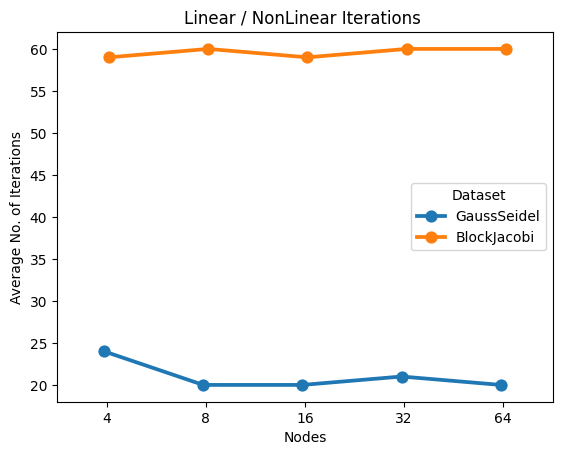

In [42]:
avgIters = []
#Creates a ne wempty list to loop over and store the avgIterations values from the df Dataframe, it then takes the average number of the ratio of linear/nonlinear iterations for each unique core count in a Dataset
for dataset in df['Dataset'].unique():
    datagroup = df[df['Dataset'] == dataset]
    for core in df['Cores'].unique():
        coreGroup = datagroup[datagroup['Cores'] == core]
        avgIterations = np.mean(coreGroup['Linear/Nonlinear'])
        avgIters.append({
                'Average Iterations': avgIterations,
                'Cores': core,
                'Dataset': dataset

            })
        
avgItersDf = pd.DataFrame(avgIters)

plt.figure()


sns.pointplot( data=avgItersDf, x='Cores', y='Average Iterations', hue='Dataset', dodge= True )
plt.xlabel('Nodes')
plt.ylabel('Average No. of Iterations')


plt.title(f'Linear / NonLinear Iterations ')
#plt.savefig(f'No of Iterations', dpi =300)

Creates a new empty list to loop over and store the avgIterations values from the df Dataframe, it then takes the average number of the ratio of linear/nonlinear iterations for each unique core count in a Dataset

In [43]:
#df_4threads = df[df['Dataset'] == '4threads']

df_GaussSeidel = df[df['Dataset'] == 'GaussSeidel']

df_BlockJacobi = df[df["Dataset"] == 'BlockJacobi']

altered_BlockJacobi = df_BlockJacobi.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name ='Timer', value_name= 'Time')
#altered_4threads = df_4threads.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name ='Timer', value_name= 'Time')
altered_GaussSeidel = df_GaussSeidel.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name ='Timer', value_name= 'Time')



timers = ['Albany Piro', 'Total Fill Time', 'Precond', 'Total Lin']

cores = [4,8,16,32,64]

df_GaussSeidel

,Albany Piro,Total Fill Time,Precond,Total Lin,No of NonLinear Iterations,No of Linear Iterations,Cores,Run,Dataset,Linear/Nonlinear
0,31.16530,11.47480,5.19789,14.29670,13.0,323.0,4,1,GaussSeidel,24.0
1,31.50760,11.49930,5.37791,14.41110,13.0,323.0,4,2,GaussSeidel,24.0
2,31.26400,11.46480,5.29685,14.31940,13.0,323.0,4,3,GaussSeidel,24.0
3,31.14470,11.49550,5.19891,14.24160,13.0,323.0,4,4,GaussSeidel,24.0
4,31.19250,11.51220,5.21599,14.27730,13.0,323.0,4,5,GaussSeidel,24.0
5,17.72300,5.86421,5.24387,6.40740,13.0,261.0,8,1,GaussSeidel,20.0
6,17.63520,5.83595,5.21743,6.37885,13.0,261.0,8,2,GaussSeidel,20.0
7,17.87640,5.95262,5.27414,6.42228,13.0,261.0,8,3,GaussSeidel,20.0
8,17.70410,5.84247,5.28234,6.37898,13.0,261.0,8,4,GaussSeidel,20.0
9,17.62670,5.88097,5.17688,6.36487,13.0,261.0,8,5,GaussSeidel,20.0


Splits joint 'df' Dataframe into two separate ones  (one per each dataset, can split into three in order to plot 3 datasets at once). It then uses the 'melt' function to merge the timer column names into a single column and create a new column 'Time" that stores the value time for that specific Dataset, Core count, Run, Timer.
This is done in order to use the 'hue' function in the seaborn plots



In [44]:
final_time_BlockJacobi = df_BlockJacobi.drop(['No of NonLinear Iterations', 'No of Linear Iterations', 'Linear/Nonlinear'], axis =1)

final_time_GaussSeidel = df_GaussSeidel.drop(['No of NonLinear Iterations', 'No of Linear Iterations', 'Linear/Nonlinear'], axis =1)

#final_time_4threads = df_4threads.drop(['No of NonLinear Iterations', 'No of Linear Iterations', 'Linear/Nonlinear'], axis =1)

final_BlockJacobi_melt = final_time_BlockJacobi.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name ='Timer', value_name= 'Time')

final_GaussSeidel_melt = final_time_GaussSeidel.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name ='Timer', value_name= 'Time')

#final_4threads_melt = final_time_4threads.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name ='Timer', value_name= 'Time')

Also create lists for the core count and names of timers looking to be analyzed


In [45]:
#Check outline of new altered datasets
altered_GaussSeidel


,Cores,Run,Dataset,Timer,Time
0,4,1,GaussSeidel,Albany Piro,31.1653
1,4,2,GaussSeidel,Albany Piro,31.5076
2,4,3,GaussSeidel,Albany Piro,31.2640
3,4,4,GaussSeidel,Albany Piro,31.1447
4,4,5,GaussSeidel,Albany Piro,31.1925
...,...,...,...,...,...
170,64,1,GaussSeidel,Linear/Nonlinear,20.0000
171,64,2,GaussSeidel,Linear/Nonlinear,20.0000
172,64,3,GaussSeidel,Linear/Nonlinear,20.0000
173,64,4,GaussSeidel,Linear/Nonlinear,20.0000


In [46]:
#efficiency_df_4threads = pd.DataFrame()
efficiency_df_GaussSeidel = pd.DataFrame()
efficiency_df_BlockJacobi = pd.DataFrame()

for timer in timers:
        
        efficiency_df_BlockJacobi[f"Efficiency {timer}"] = efficiency(df_BlockJacobi, timer,cores)
        #efficiency_df_4threads[f"Efficiency {timer}"] = efficiency(df_4threads, timer,cores)
        efficiency_df_GaussSeidel[f"Efficiency {timer}"] = efficiency(df_GaussSeidel, timer,cores)

        df_sorted_BlockJacobi = df_BlockJacobi.sort_values(by=['Run', 'Cores',])
        #df_sorted_4threads = df_4threads.sort_values(by=['Run', 'Cores', ]) 
        df_sorted_GaussSeidel = df_GaussSeidel.sort_values(by=['Run', 'Cores', ]) 


        df_final_BlockJacobi = pd.concat([df_sorted_BlockJacobi.reset_index(drop=True), efficiency_df_BlockJacobi.reset_index(drop=True)], axis=1)
        #df_final_4threads =  pd.concat([df_sorted_4threads.reset_index(drop=True), efficiency_df_4threads.reset_index(drop=True)], axis=1)
        df_final_GaussSeidel = pd.concat([df_sorted_GaussSeidel.reset_index(drop=True), efficiency_df_GaussSeidel.reset_index(drop=True)], axis=1)
#Check dataframe format
df_final_GaussSeidel

[45.4677  23.8241  13.2521   8.60897  6.95281]
95.42375157928316
89.8880177481305
76.9668148454461
61.91000473189976
[45.5939  23.9401  13.4484   8.73421  6.97944]
95.22495728923437
89.00724249724875
76.98692841138465
62.57099423449445
[45.4442  23.7997  13.1998   8.33061  6.89183]
95.47221183460296
90.1517447234049
79.22469062889752
60.43830158317892
[45.4603  23.6982  13.716    8.66532  7.10956]
95.91509059759812
86.38888888888889
79.14306684577143
60.94132407631414
[45.5063  24.4045  13.1982   8.45776  6.93452]
93.23342006597144
92.45389522813716
78.02420499044665
60.98302405934369
[31.1653  17.723   11.5672   9.81603  8.93613]
87.9233199796874
76.60885953385434
58.919950326150186
54.92327215472469
[31.5076  17.6352  11.5604   9.56827  8.86055]
89.33156414443839
76.27417736410506
60.41008458164329
53.99365727861137
[31.264   17.8764  11.6219   9.7772   8.90708]
87.44489942046498
76.90825080236449
59.433682444871735
54.88442901601872
[31.1447  17.7041  11.6057   9.72636  8.99026]
87.

,Albany Piro,Total Fill Time,Precond,Total Lin,No of NonLinear Iterations,No of Linear Iterations,Cores,Run,Dataset,Linear/Nonlinear,Efficiency Albany Piro,Efficiency Total Fill Time,Efficiency Precond,Efficiency Total Lin
0,31.16530,11.47480,5.19789,14.29670,13.0,323.0,4,1,GaussSeidel,24.0,100.000000,100.000000,100.000000,100.000000
1,17.72300,5.86421,5.24387,6.40740,13.0,261.0,8,1,GaussSeidel,20.0,87.923320,97.837560,49.561583,111.563973
2,11.56720,3.06601,4.56419,3.73793,13.0,260.0,16,1,GaussSeidel,20.0,76.608860,95.632597,57.445790,85.707865
3,9.81603,1.72624,4.67583,3.19381,13.0,281.0,32,1,GaussSeidel,21.0,58.919950,88.806018,48.806201,58.518353
4,8.93613,1.05588,4.85883,2.79474,13.0,267.0,64,1,GaussSeidel,20.0,54.923272,81.744138,48.116831,57.139662
5,31.50760,11.49930,5.37791,14.41110,13.0,323.0,4,2,GaussSeidel,24.0,100.000000,100.000000,100.000000,100.000000
6,17.63520,5.83595,5.21743,6.37885,13.0,261.0,8,2,GaussSeidel,20.0,89.331564,98.521235,51.537922,112.960016
7,11.56040,3.07826,4.55703,3.73568,13.0,260.0,16,2,GaussSeidel,20.0,76.274177,94.793000,57.245947,85.377361
8,9.56827,1.71721,4.51014,3.12903,13.0,281.0,32,2,GaussSeidel,21.0,60.410085,89.629690,50.519829,59.693899
9,8.86055,1.05022,4.79118,2.78847,13.0,267.0,64,2,GaussSeidel,20.0,53.993657,81.754775,47.067111,56.106575


initializes 2 empty dataframes and fills them with values obtained from calling the efficiency function on a specific timer from a database, it then combines that value with the original database and sorts it by runs and cores to have it ordered 

In [55]:
#df_eff_4threads = df_final_4threads.drop(['Albany Piro', 'Total Fill Time', 'Precond', 'Total Lin', 'No of Linear Iterations', "No of NonLinear Iterations", 'Linear/Nonlinear'], axis =1 )
    
#eff_plot_4threads = df_eff_4threads.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name = 'Efficiency', value_name = 'Percentage')


df_eff_GaussSeidel = df_final_GaussSeidel.drop(['Albany Piro', 'Total Fill Time', 'Precond', 'Total Lin', 'No of Linear Iterations', "No of NonLinear Iterations", 'Linear/Nonlinear'], axis =1 )

eff_plot_GaussSeidel = df_eff_GaussSeidel.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name = 'Efficiency', value_name = 'Percentage')


df_eff_BlockJacobi = df_final_BlockJacobi.drop(['Albany Piro', 'Total Fill Time', 'Precond', 'Total Lin', 'No of Linear Iterations', "No of NonLinear Iterations", 'Linear/Nonlinear'], axis =1 )
eff_plot_BlockJacobi = df_eff_BlockJacobi.melt(id_vars=['Cores', 'Run', 'Dataset'], var_name = 'Efficiency', value_name = 'Percentage')

unique_effs = eff_plot_GaussSeidel['Efficiency'].unique()



#Re-combine dataframes
df_combined = pd.concat([eff_plot_GaussSeidel, eff_plot_BlockJacobi], axis=0)
#Check Dataframe format
eff_plot_GaussSeidel
df_combined

,Cores,Run,Dataset,Efficiency,Percentage
0,4,1,GaussSeidel,Efficiency Albany Piro,100.000000
1,8,1,GaussSeidel,Efficiency Albany Piro,87.923320
2,16,1,GaussSeidel,Efficiency Albany Piro,76.608860
3,32,1,GaussSeidel,Efficiency Albany Piro,58.919950
4,64,1,GaussSeidel,Efficiency Albany Piro,54.923272
...,...,...,...,...,...
95,4,5,BlockJacobi,Efficiency Total Lin,100.000000
96,8,5,BlockJacobi,Efficiency Total Lin,102.646660
97,16,5,BlockJacobi,Efficiency Total Lin,103.930371
98,32,5,BlockJacobi,Efficiency Total Lin,91.322990


Finally, each dataframe is restructured to be shown in the above format, split into type of efficiency and 'Percentage' value, to make it easier to plot

C:\Users\rcaller\AppData\Local\Temp\ipykernel_28948\2962365509.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot( data=eff_df_combined, x=eff_df_combined['Cores'], y=eff_df_combined['Percentage'], errorbar = scitest, capsize = 0.3, errwidth= 0.75, join =True , dodge = True, hue = 'Dataset')
C:\Users\rcaller\AppData\Local\Temp\ipykernel_28948\2962365509.py:15: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  sns.pointplot( data=eff_df_combined, x=eff_df_combined['Cores'], y=eff_df_combined['Percentage'], errorbar = scitest, capsize = 0.3, errwidth= 0.75, join =True , dodge = True, hue = 'Dataset')
C:\Users\rcaller\AppData\Local\Temp\ipykernel_28948\2962365509.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot( data=eff_df_combined, x=eff_df_combined['Cores'], y=eff_df_combined['Percentage'], 

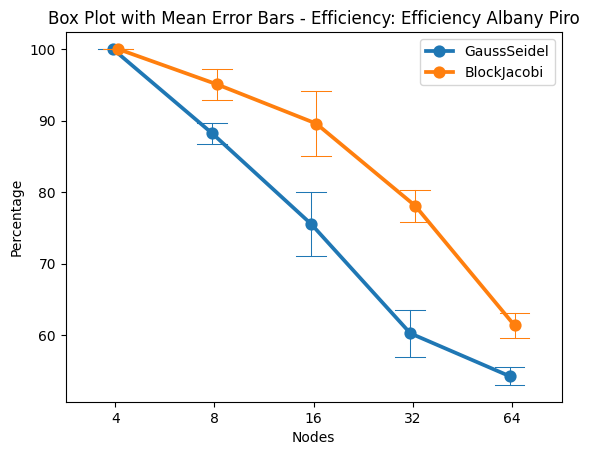

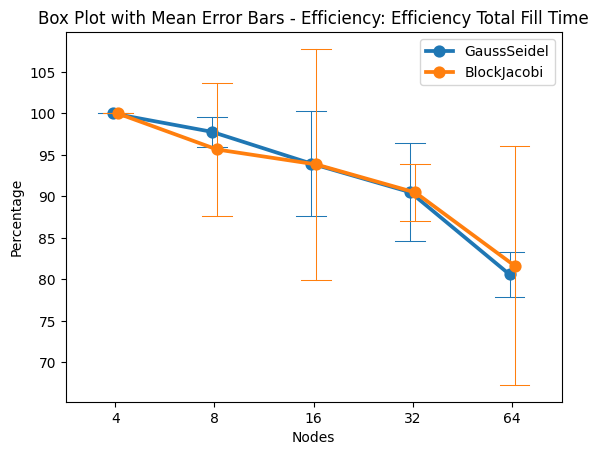

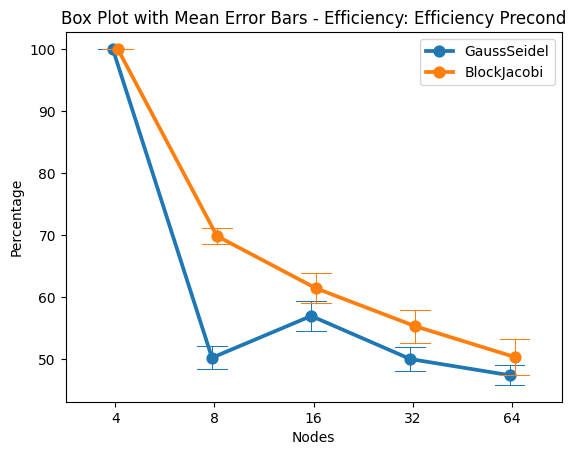

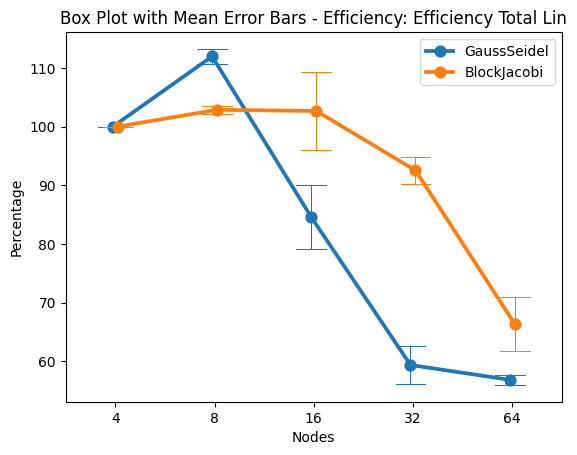

In [65]:
for i, timer in enumerate(unique_effs):
    #eff_df_GaussSeidel = eff_plot_GaussSeidel[eff_plot_GaussSeidel['Efficiency'] == timer]
    #eff_df_4threads = eff_plot_4threads[eff_plot_4threads['Efficiency'] == timer]
    #eff_df_BlockJacobi = eff_plot_BlockJacobi[eff_plot_BlockJacobi['Efficiency'] == timer]

    eff_df_combined = df_combined[df_combined['Efficiency'] == timer]
    plt.figure()
    #unique_xs= sorted(eff_df['Cores'].unique())
    #sns.pointplot( data=eff_df_4threads, x=eff_df_4threads['Cores'], y=eff_df_4threads['Percentage'], errorbar = scitest, capsize = 0.3, color = 'orange', errwidth= 0.75, join =True, dodge= True )
    #sns.boxplot(data=eff_df_4threads, x=eff_df_4threads['Cores'],    y=eff_df_4threads['Percentage'], showcaps= False, linewidth= 0.5, color= 'orange', label = '4threads', whis=(0,100), showmeans =True, meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"blue"}, dodge= True)

    #sns.pointplot( data=eff_df_GaussSeidel, x=eff_df_GaussSeidel['Cores'], y=eff_df_GaussSeidel['Percentage'], errorbar = scitest, capsize = 0.3, color= 'blue', errwidth= 0.75, join =True , dodge = True)
    #sns.boxplot(data=eff_df_GaussSeidel, x=eff_df_GaussSeidel['Cores'],    y=eff_df_GaussSeidel['Percentage'], showcaps= False, linewidth= 0.5, color= 'blue', label = 'GaussSeidel', whis=(0,100), showmeans =True, meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"blue"}, dodge= True)
    
    sns.pointplot( data=eff_df_combined, x=eff_df_combined['Cores'], y=eff_df_combined['Percentage'], errorbar = scitest, capsize = 0.3, errwidth= 0.75, join =True , dodge = True, hue = 'Dataset')
    #sns.boxplot(data=eff_df_combined, x=eff_df_combined['Cores'],    y=eff_df_combined['Percentage'], showcaps= False, linewidth= 0.5, whis=(0,100), showmeans =True, meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"blue"}, hue = 'Dataset')

    
    plt.xlabel('Nodes')
    plt.ylabel('Percentage')
    plt.legend()
    plt.title(f'Box Plot with Mean Error Bars - Efficiency: {timer}')
    #plt.savefig(f'Efficiency {timer} Boxplot with mean errror bars', dpi =300)

Plot Efficiency Graphs

In [49]:
mean_list = []

for core in cores:
    
    core_group_BlockJacobi = df_BlockJacobi[df_BlockJacobi['Cores']== core]
    core_group_GaussSeidel = df_GaussSeidel[df_GaussSeidel['Cores']== core]

    for timer in timers:

        log_mean, log_lower, log_upper= trimmed_ttest_bounds(np.log(core_group_GaussSeidel[timer]), np.log(core_group_BlockJacobi[timer]))
        mean_list.append({
            'Cores': core,
            'Timer': timer,
            'Mean Difference': log_mean,
            'Bounds': (log_lower,log_upper)
        })
mean_df = pd.DataFrame(mean_list)

0.004733925366082073
0.0013197599280053377
0.0016706592551164556
0.0009875135298259609
0.014889345432209006
0.0058637206426448395
0.004444959336340026
0.0016846365075368728
0.005659532398691589
0.011509665350224725
0.007937102098688267
0.04217937261328316
0.008257093985585395
0.009148314317620513
0.003685040918080546
0.003946757452872667
0.026842084443380872
0.016543633095819996
0.03377539669412684
0.048292986606220896
0.014248824011359316
0.012664461824013623
0.02963546792000334
0.030416376984599855
0.010059132252582571
0.019170225584588828
0.011498921987435006
0.06054329372868823
0.014368344794159731
0.019416756649461412
0.01019275041494439
0.029765019109596422
0.011424432928479288
0.011759387973636811
0.024155804820156553
0.04888742048429895
0.013437128764274602
0.013741189023449361
0.003563889608120771
0.01135174939199945


C:\Users\rcaller\AppData\Local\Temp\ipykernel_28948\2125254950.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot( data=timer_df_GaussSeidel, x=timer_df_GaussSeidel['Cores'], y=timer_df_GaussSeidel['Time'], errorbar = scitest, capsize = 0.3, color= 'blue', errwidth= 0.75, join =True, linewidth = 1 )
C:\Users\rcaller\AppData\Local\Temp\ipykernel_28948\2125254950.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  sns.pointplot( data=timer_df_GaussSeidel, x=timer_df_GaussSeidel['Cores'], y=timer_df_GaussSeidel['Time'], errorbar = scitest, capsize = 0.3, color= 'blue', errwidth= 0.75, join =True, linewidth = 1 )
C:\Users\rcaller\AppData\Local\Temp\ipykernel_28948\2125254950.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot( data=timer_df_BlockJacobi, x=timer_df_BlockJacobi['Cores'], y=timer

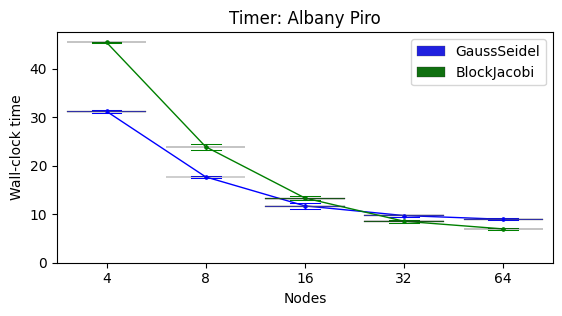

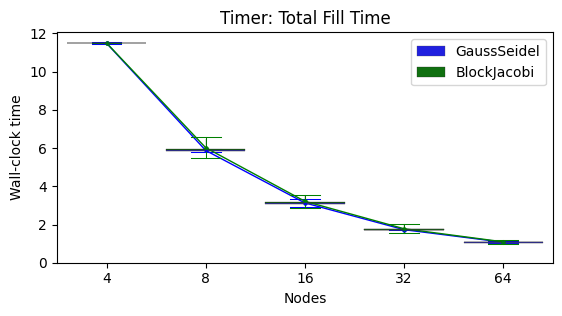

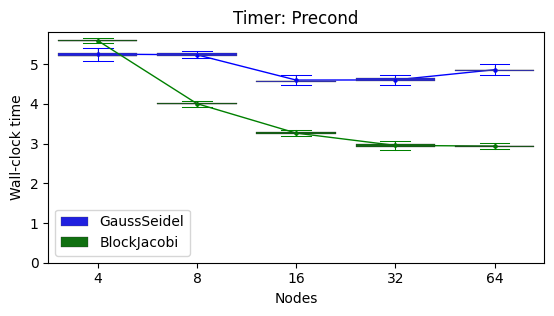

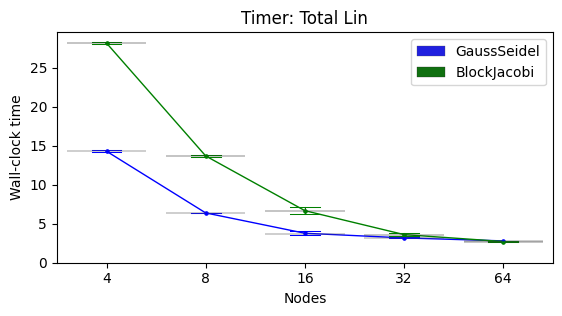

In [50]:
unique_timers = final_BlockJacobi_melt['Timer'].unique()

for i, timer in enumerate(unique_timers):
    # Filter dataframe for the current timer
    #timer_df_4threads = final_4threads_melt[final_4threads_melt['Timer'] == timer]
    timer_df_GaussSeidel = final_GaussSeidel_melt[final_GaussSeidel_melt['Timer'] == timer]
    timer_df_BlockJacobi = final_BlockJacobi_melt[final_BlockJacobi_melt['Timer'] == timer]

    
    plt.figure()
    unique_sorted_BlockJacobi= sorted(timer_df_BlockJacobi['Cores'].unique())
    #4threads
    #sns.pointplot( data=timer_df_4threads, x=timer_df_4threads['Cores'], y=timer_df_4threads['Time'], errorbar = scitest, capsize = 0.3, color = 'orange', errwidth= 0.75, join =True, linewidth = 1 )
    #sns.boxplot(data=timer_df_4threads, x=timer_df_4threads['Cores'],    y=timer_df_4threads['Time'], showcaps= False, linewidth= 0.2, color= 'orange', label = '4threads', whis=(0,100), showmeans =True, meanprops={"marker":"s","markerfacecolor":"orange", "markeredgecolor":"orange", "markersize": 1})
    #GaussSeidel
    sns.pointplot( data=timer_df_GaussSeidel, x=timer_df_GaussSeidel['Cores'], y=timer_df_GaussSeidel['Time'], errorbar = scitest, capsize = 0.3, color= 'blue', errwidth= 0.75, join =True, linewidth = 1 )
    sns.boxplot(data=timer_df_GaussSeidel, x=timer_df_GaussSeidel['Cores'],    y=timer_df_GaussSeidel['Time'], showcaps= False, linewidth= 0.2, color= 'blue',  label = 'GaussSeidel' , whis=(0,100), showmeans =True, meanprops={"marker":"s","markerfacecolor":"blue", "markeredgecolor":"blue", "markersize": 1})

    sns.pointplot( data=timer_df_BlockJacobi, x=timer_df_BlockJacobi['Cores'], y=timer_df_BlockJacobi['Time'], errorbar = scitest, capsize = 0.3, color= 'green', errwidth= 0.75, join =True, linewidth = 1 )
    sns.boxplot(data=timer_df_BlockJacobi, x=timer_df_BlockJacobi['Cores'],    y=timer_df_BlockJacobi['Time'], showcaps= False, linewidth= 0.2, color= 'green',  label = 'BlockJacobi' , whis=(0,100), showmeans =True, meanprops={"marker":"s","markerfacecolor":"green", "markeredgecolor":"green", "markersize": 1})
        

    #meanprops{"marker":"s","markerfacecolor":"blue", "markeredgecolor":"blue"}
    """ for core in cores:

        core_df = mean_df[mean_df['Cores'] ==core]

        sci_timer = mean_df[mean_df['Timer'] == timer]
        table_data = sci_timer[['Cores', 'Mean Difference', 'Bounds']].copy()
        table_data['Bounds'] = table_data['Bounds'].apply(lambda x: f'({np.exp(x[0]):.2f}, {np.exp(x[1]):.2f})')
        table_data['Mean Difference'] = table_data['Mean Difference'].apply(lambda x: f'{np.exp(x):.2f}')
        
        
        table_data = table_data.values

    col_labels = ["Nodes", 'MPI Speedup' , "99% CI: (LL, UL)" ]
    table = plt.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='bottom', bbox=[0, -0.75, 1, 0.5]) """


    plt.subplots_adjust(bottom=0.4)

    #sns.pointplot(data = ideal_time_df, x = 'Cores', y='Ideal Times', marker='o', label ='Ideal-Time', linestyle='--')
    plt.xlabel('Nodes')
    plt.ylabel('Wall-clock time')
    plt.legend()
    plt.ylim(ymin = 0)
    plt.title(f'Timer: {timer}')
    #plt.savefig(f'{timer} Boxplot with mean errror bars', dpi =300)